Matplotlib is building the font cache; this may take a moment.


        date   sales  price  promotion  temperature  holiday  day_of_week  \
0 2025-01-01   89.30  10.08          0         3.10        1            2   
1 2025-01-02  117.17   8.70          1         2.04        0            3   
2 2025-01-03   95.25  10.07          0         1.33        0            4   
3 2025-01-04  114.66   9.61          0         2.76        0            5   
4 2025-01-05  112.80  10.34          0         4.16        0            6   
5 2025-01-06   80.67   9.94          0         1.51        0            0   
6 2025-01-07   90.95  10.08          0         1.24        0            1   
7 2025-01-08  114.89  10.16          1         1.83        0            2   
8 2025-01-09   76.07   9.45          0         4.51        0            3   
9 2025-01-10   93.01  10.69          0         5.57        0            4   

   month  week_of_year       trend  
0      1             1  100.000000  
1      1             1  100.137363  
2      1             1  100.274725  
3   

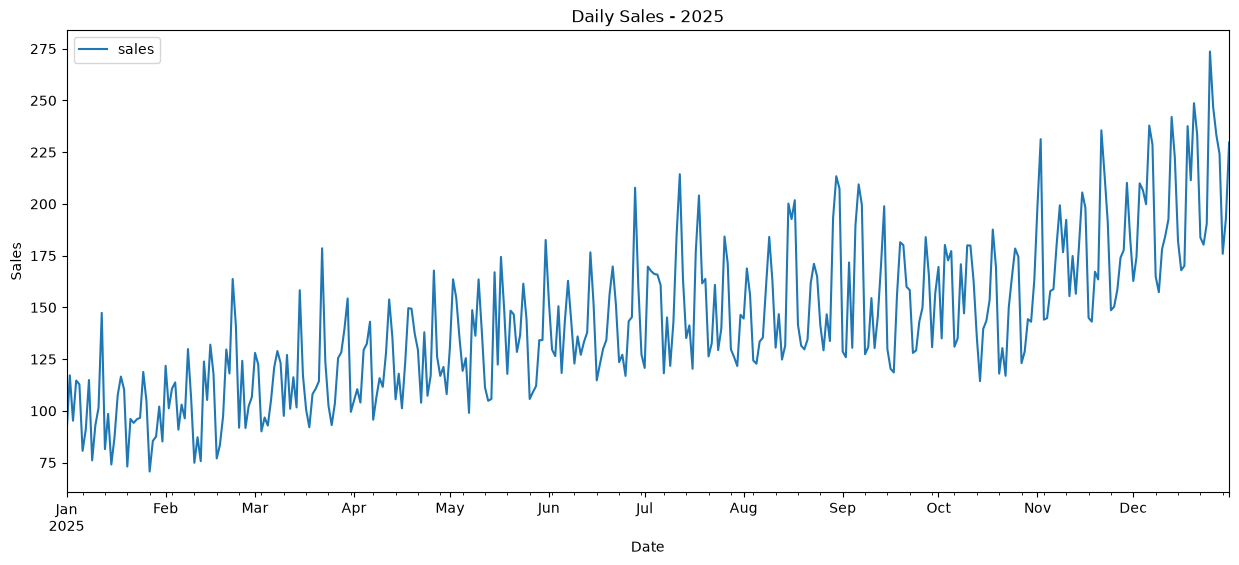

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# -------------------------------------------------------
# 1. Create one year of daily dates
# -------------------------------------------------------
dates = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    freq="D"
)

df = pd.DataFrame({
    "date": dates
})

# -------------------------------------------------------
# 2. Calendar features
# -------------------------------------------------------
df["day_of_week"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_month"] = df["date"].dt.day

# -------------------------------------------------------
# 3. Trend
# -------------------------------------------------------
# Sales gradually increase throughout the year
df["trend"] = np.linspace(100, 150, len(df))

# -------------------------------------------------------
# 4. Weekly seasonality
# -------------------------------------------------------
# Higher sales toward the weekend
weekly_pattern = {
    0: 0.90,  # Monday
    1: 0.92,  # Tuesday
    2: 0.95,  # Wednesday
    3: 1.00,  # Thursday
    4: 1.10,  # Friday
    5: 1.25,  # Saturday
    6: 1.15   # Sunday
}

df["weekly_factor"] = df["day_of_week"].map(weekly_pattern)

# -------------------------------------------------------
# 5. Monthly/annual seasonality
# -------------------------------------------------------
monthly_pattern = {
    1: 0.90,
    2: 0.92,
    3: 0.98,
    4: 1.00,
    5: 1.05,
    6: 1.08,
    7: 1.10,
    8: 1.08,
    9: 1.02,
    10: 1.05,
    11: 1.15,
    12: 1.30
}

df["monthly_factor"] = df["month"].map(monthly_pattern)

# -------------------------------------------------------
# 6. Promotion
# -------------------------------------------------------
# Approximately 15% of days have promotions
df["promotion"] = np.random.choice(
    [0, 1],
    size=len(df),
    p=[0.85, 0.15]
)

# -------------------------------------------------------
# 7. Holiday
# -------------------------------------------------------
# Example holidays
holidays = pd.to_datetime([
    "2025-01-01",
    "2025-04-18",
    "2025-04-21",
    "2025-05-01",
    "2025-10-03",
    "2025-12-25",
    "2025-12-26"
])

df["holiday"] = df["date"].isin(holidays).astype(int)

# -------------------------------------------------------
# 8. Temperature
# -------------------------------------------------------
# Simulated seasonal temperature
day_of_year = df["date"].dt.dayofyear

df["temperature"] = (
    12
    + 10 * np.sin(2 * np.pi * (day_of_year - 80) / 365)
    + np.random.normal(0, 2, len(df))
)

# -------------------------------------------------------
# 9. Price
# -------------------------------------------------------
# Base price with small random fluctuations
df["price"] = (
    10
    + np.random.normal(0, 0.5, len(df))
)

# Promotional days have slightly lower prices
df.loc[df["promotion"] == 1, "price"] *= 0.90

# -------------------------------------------------------
# 10. Generate sales
# -------------------------------------------------------

base_sales = 100

df["sales"] = (
    base_sales
    * df["weekly_factor"]
    * df["monthly_factor"]
    * (df["trend"] / 100)
)

# Promotion increases sales
df["sales"] *= np.where(
    df["promotion"] == 1,
    1.25,
    1.0
)

# Holidays increase sales slightly
df["sales"] *= np.where(
    df["holiday"] == 1,
    1.15,
    1.0
)

# Add random noise
noise = np.random.normal(
    loc=0,
    scale=8,
    size=len(df)
)

df["sales"] += noise

# Sales cannot be negative
df["sales"] = df["sales"].clip(lower=0)

# Round values
df["sales"] = df["sales"].round(2)
df["price"] = df["price"].round(2)
df["temperature"] = df["temperature"].round(2)

# -------------------------------------------------------
# 11. Select useful columns
# -------------------------------------------------------

df = df[
    [
        "date",
        "sales",
        "price",
        "promotion",
        "temperature",
        "holiday",
        "day_of_week",
        "month",
        "week_of_year",
        "trend"
    ]
]

# -------------------------------------------------------
# 12. Display
# -------------------------------------------------------

print(df.head(10))

print("\nShape:")
print(df.shape)

print("\nSummary:")
print(df.describe())

# -------------------------------------------------------
# 13. Plot sales
# -------------------------------------------------------

df.plot(
    x="date",
    y="sales",
    figsize=(15, 6),
    title="Daily Sales - 2025"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# -------------------------------------------------------
# 14. Save to CSV
# -------------------------------------------------------

df.to_csv(
    "sales_timeseries_2025.csv",
    index=False
)